Figure 3a — number of DE TFs per cluster (Patient 1)


In [1]:
from pathlib import Path
import warnings
import mudata
import muon
import scanpy as sc

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Cannot join columns")
mudata.set_options(pull_on_update=False)

DATA = Path("PATH_TO_DATA")
adata_mvi = sc.read_h5ad(DATA / "TALL_Website/Object/PB2/Teaseq_Multi_VI_PB2_Cleaned.h5ad")
mdata_pb2 = muon.read(DATA / "TotalVI/New/PB2/TotalVI_PB2_TEAseq_CLEAN_TF.h5mu")


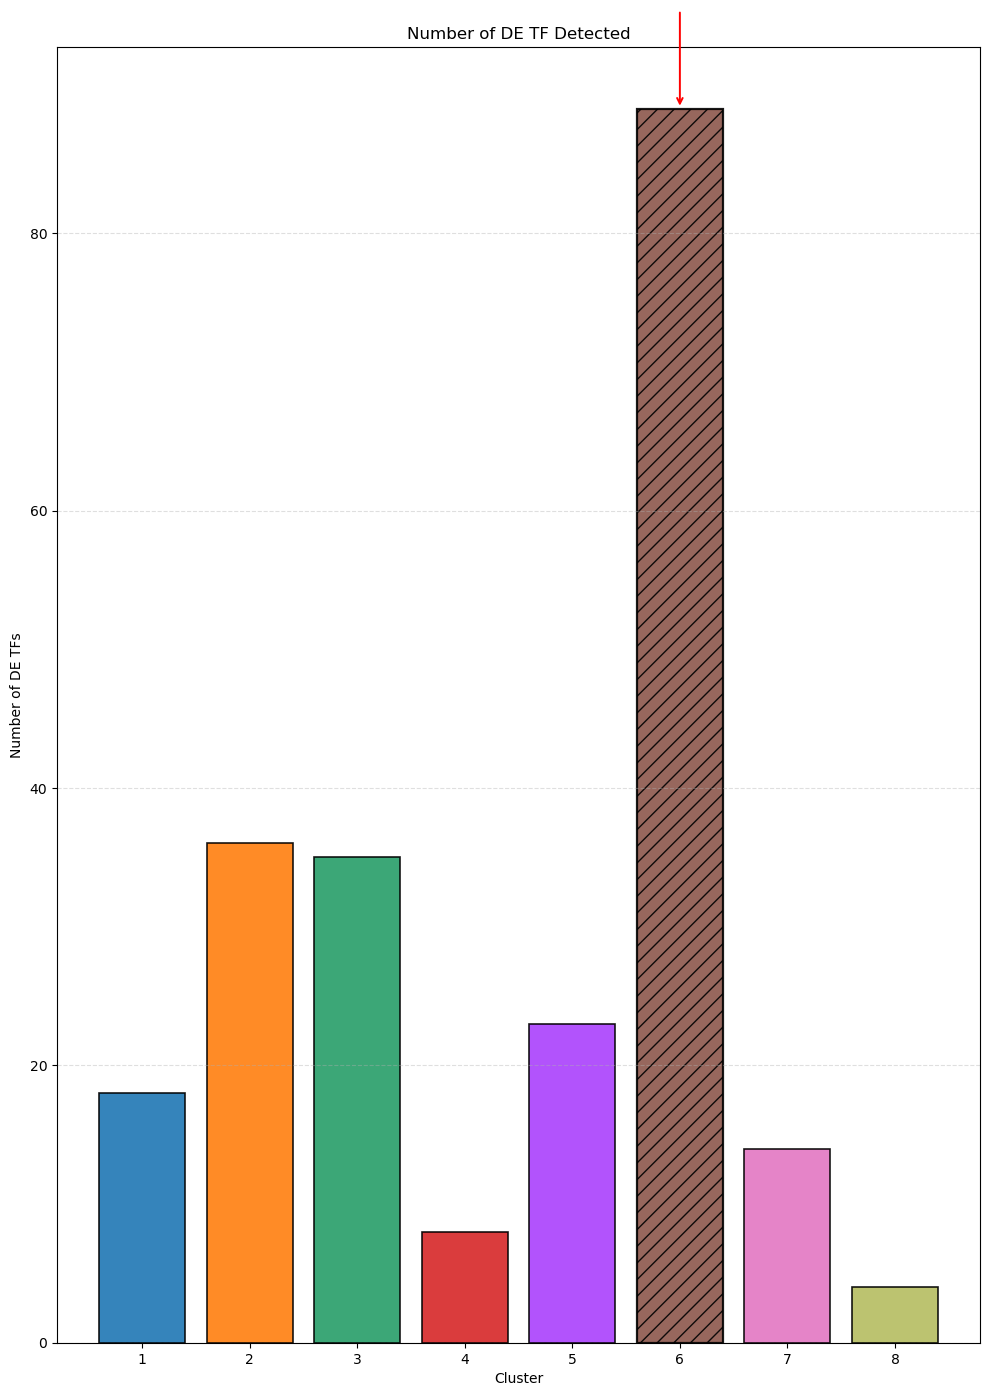

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(DATA / "TotalVI/New/PB2/DE/filtered_rna.csv")
ROOT = "6"


def plot_de_tf_detected_bar(df, adata_mvi, title="Number of DE TF Detected"):
    gene_columns = df.columns[1:]
    gene_counts = df[gene_columns].count()

    if "Cluster_Final" not in adata_mvi.obs:
        raise KeyError("`Cluster_Final` missing from adata_mvi.obs")
    if "Cluster_Final_colors" not in adata_mvi.uns:
        raise KeyError("`Cluster_Final_colors` missing from adata_mvi.uns")

    cl = adata_mvi.obs["Cluster_Final"]
    if not isinstance(cl.dtype, pd.CategoricalDtype):
        adata_mvi.obs["Cluster_Final"] = cl.astype("category")
        cl = adata_mvi.obs["Cluster_Final"]

    categories = [str(c) for c in cl.cat.categories]
    colors = list(adata_mvi.uns["Cluster_Final_colors"])
    if len(colors) > len(categories):
        colors = colors[: len(categories)]
    if len(colors) < len(categories):
        raise ValueError("Not enough Cluster_Final colors in adata_mvi")

    cat2color = dict(zip(categories, colors))

    def get_color(col):
        s = str(col)
        if s in cat2color:
            return cat2color[s]
        return None

    bar_colors = [get_color(c) for c in gene_columns]
    missing = [c for c, colr in zip(gene_columns, bar_colors) if colr is None]
    if missing:
        raise ValueError(
            "These df columns do not match Cluster_Final categories in adata_mvi:\n"
            f"{missing}"
        )

    x = np.arange(len(gene_columns))
    fig, ax = plt.subplots(figsize=(10, 14))
    bars = ax.bar(
        x,
        gene_counts.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
    )
    labels = [str(c) for c in gene_columns]
    if ROOT in labels:
        i = labels.index(ROOT)
        bars[i].set_hatch("//")
        bars[i].set_linewidth(1.6)
        ax.annotate(
            "",
            xy=(i, gene_counts.values[i]),
            xytext=(i, gene_counts.values[i] + 0.08 * float(gene_counts.max())),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.4),
        )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Number of DE TFs")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_de_tf_detected_bar(df, adata_mvi, title="Number of DE TF Detected")


Figure 3b — CSC TF dot plot (Patient 1)


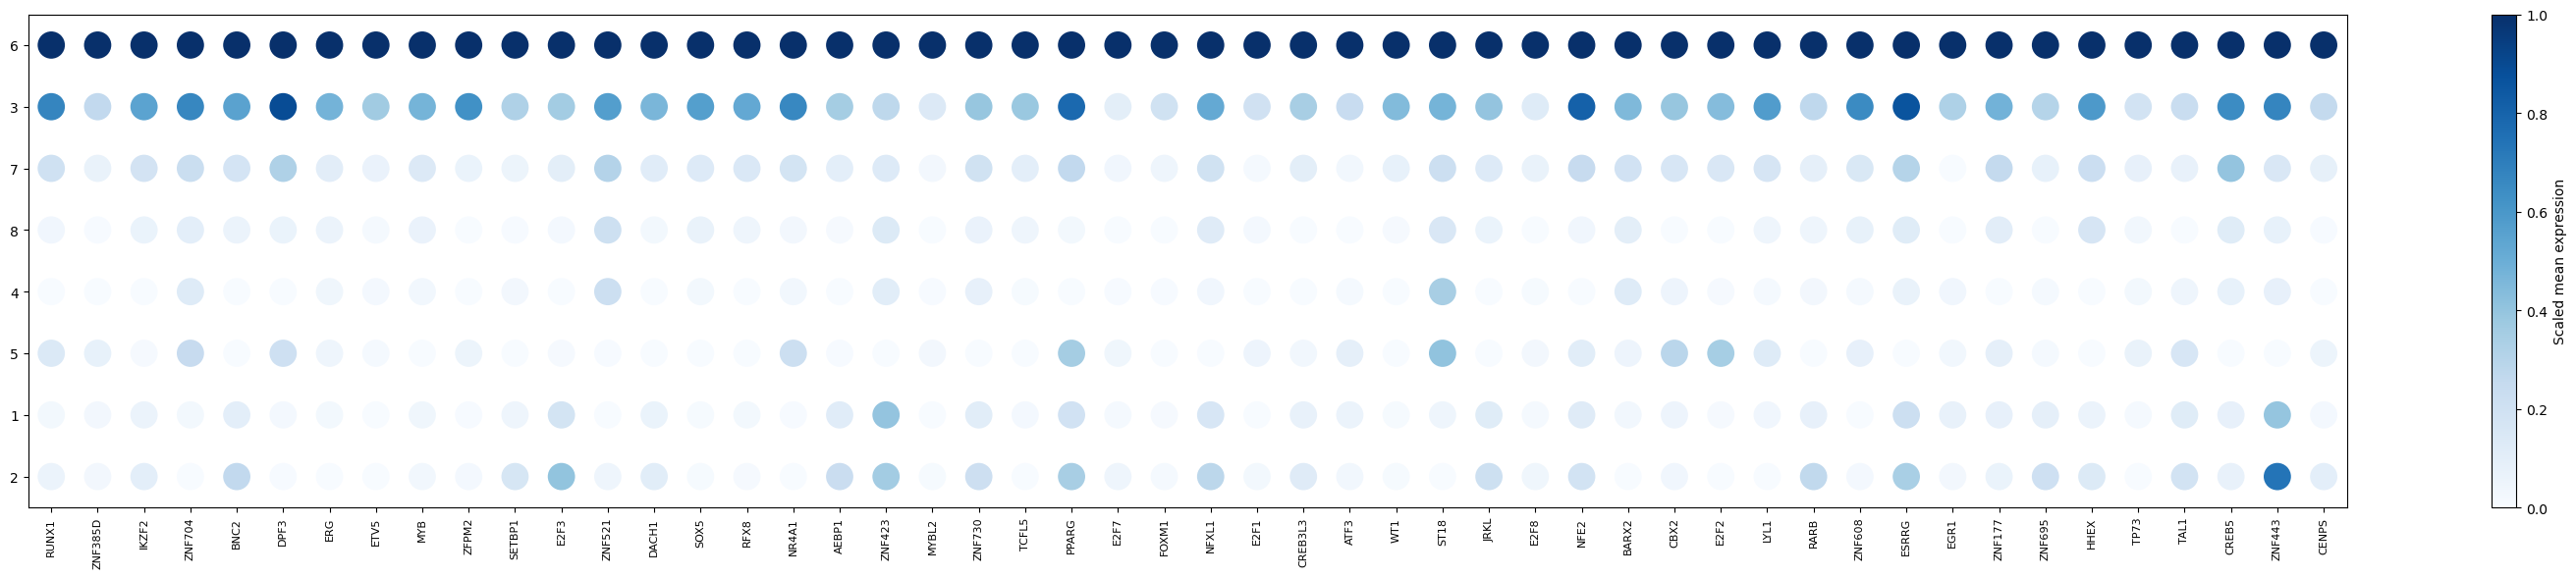

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- cluster order (trajectory, top → bottom on plot) ----
# Change this list to use a different cluster order.
CLUSTER_ORDER = ["6", "3", "7", "8", "4", "5", "1", "2"]

# ---- load genes ----
filtered_rna_df = pd.read_csv(DATA / "TotalVI/New/PB2/DE/filtered_rna.csv")

filtered_rna = {
    col: filtered_rna_df[col].dropna().tolist()
    for col in filtered_rna_df.columns
    if col != "Unnamed: 0"
}

genes_cluster6 = [
    "E2F7", "MYBL2", "WT1", "E2F8", "ZFPM2", "ZNF385D", "ETV5",
    "SOX5", "TP73", "ERG", "RFX8", "ZNF695", "CENPS", "FOXM1",
    "DACH1", "NR4A1", "E2F1", "E2F2", "ZNF704", "CREB3L3",
    "LYL1", "SETBP1", "ST18", "HHEX", "ZNF608", "BNC2",
    "NFE2", "MYB", "TCFL5", "JRKL", "EGR1", "ATF3", "BARX2",
    "TAL1", "CREB5", "IKZF2", "ZNF423", "RARB", "CBX2",
    "AEBP1", "ESRRG", "PPARG", "ZNF521", "ZNF177", "DPF3",
    "E2F3", "RUNX1", "NFXL1", "ZNF730", "ZNF443",
]

# ---- data ----
rna = mdata_pb2.mod["rna_subset"].copy()
rna.X = rna.layers["denoised_rna"]

# ---- keep ONLY genes present in BOTH lists AND dataset ----
genes = filtered_rna["6"]
genes = [g for g in genes if g in genes_cluster6 and g in rna.var_names]

# ---- matrix ----
X = rna[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

groups = rna.obs["leiden_totalVI"].astype(str).values

df = pd.DataFrame(X, columns=genes)
df["group"] = groups

mean = df.groupby("group").mean()
pct = df.drop(columns="group").gt(0).groupby(df["group"]).mean()

# restrict + order clusters
clusters_present = [c for c in CLUSTER_ORDER if c in mean.index.astype(str)]
mean = mean.loc[clusters_present]
pct = pct.loc[clusters_present]

# Scanpy-style scaling
mean_scaled = (mean - mean.min()) / (mean.max() - mean.min() + 1e-9)

# ---- staircase gene order ----
# Each gene is ordered by its peak cluster along the trajectory,
# then by decreasing expression in that cluster.
cluster_to_idx = {c: i for i, c in enumerate(CLUSTER_ORDER)}
peak_cluster = mean[genes].idxmax(axis=0)

genes_ordered = sorted(
    genes,
    key=lambda g: (
        cluster_to_idx.get(str(peak_cluster[g]), len(CLUSTER_ORDER)),
        -float(mean.loc[peak_cluster[g], g]),
    ),
)

mean = mean[genes_ordered]
pct = pct[genes_ordered]
mean_scaled = mean_scaled[genes_ordered]

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(max(12, len(genes_ordered) * 0.6), 6))

x_pos = np.arange(len(genes_ordered))

for i, cluster in enumerate(clusters_present):
    ax.scatter(
        x_pos,
        np.full(len(x_pos), i),
        s=pct.loc[cluster].values * 400,
        c=mean_scaled.loc[cluster].values,
        cmap="Blues",
        vmin=0,
        vmax=1,
        edgecolors="none",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(genes_ordered, rotation=90, fontsize=8)

ax.set_yticks(np.arange(len(clusters_present)))
ax.set_yticklabels(clusters_present)

ax.set_xlim(-0.5, len(genes_ordered) - 0.5)
ax.set_ylim(-0.5, len(clusters_present) - 0.5)
ax.invert_yaxis()  # cluster 1 at the top → diagonal staircase

plt.colorbar(
    plt.cm.ScalarMappable(cmap="Blues"),
    ax=ax,
    label="Scaled mean expression",
)

plt.tight_layout()
plt.show()
